<a href="https://colab.research.google.com/github/Gaurav-Rawool/Machin-learning/blob/main/Gaurav__ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Gaurav Rawool

Batch : CE_03


Roll Number :CE-39



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [1]:
# Task 1: Import Libraries and Upload Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Create upload button
uploaded = files.upload()

# Get the uploaded file name automatically
file_name = next(iter(uploaded))

# Read the CSV file
df = pd.read_csv(file_name)

# Display dataset information
print("File uploaded successfully:", file_name)
print("Dataset Shape:", df.shape)

print("\nFirst 5 rows of the dataset:")
display(df.head())

Saving data (1).csv to data (1).csv
File uploaded successfully: data (1).csv
Dataset Shape: (569, 33)

First 5 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null 

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



========== DATA TYPES ==========
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst    

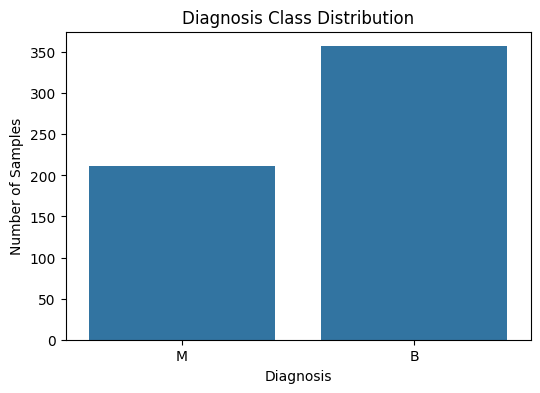

In [2]:
# Task 2: Explore the Dataset

print("========== DATASET INFORMATION ==========")
df.info()

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\n========== STATISTICAL SUMMARY ==========")
display(df.describe())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== DIAGNOSIS DISTRIBUTION ==========")
print(df['diagnosis'].value_counts())

# Plot diagnosis distribution
plt.figure(figsize=(6, 4))

sns.countplot(x='diagnosis', data=df)

plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [3]:
# Task 3: Data Cleaning and Feature/Target Selection

print("========== BEFORE CLEANING ==========")
print("Original Dataset Shape:", df.shape)

# Remove unnecessary columns
df_clean = df.drop(columns=['id', 'Unnamed: 32'])

# Convert diagnosis into numerical values
# M = Malignant = 1
# B = Benign = 0
df_clean['diagnosis'] = df_clean['diagnosis'].map({
    'M': 1,
    'B': 0
})

# Separate features and target
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

print("\n========== AFTER CLEANING ==========")
print("Cleaned Dataset Shape:", df_clean.shape)

print("\nFeature Matrix Shape (X):", X.shape)
print("Target Vector Shape (y):", y.shape)

print("\nNumber of Features:", X.shape[1])

print("\nFirst 5 rows of Feature Matrix:")
display(X.head())

print("\nFirst 5 Target Values:")
print(y.head())

print("\nTarget Class Distribution:")
print(y.value_counts())

========== BEFORE CLEANING ==========
Original Dataset Shape: (569, 33)

========== AFTER CLEANING ==========
Cleaned Dataset Shape: (569, 31)

Feature Matrix Shape (X): (569, 30)
Target Vector Shape (y): (569,)

Number of Features: 30

First 5 rows of Feature Matrix:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



First 5 Target Values:
0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

Target Class Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [4]:
# Task 4: Standardize Features

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Standardize the 30 features
X_scaled = scaler.fit_transform(X)

# Display shapes
print("========== STANDARDIZATION ==========")

print("Original Feature Shape:", X.shape)
print("Standardized Feature Shape:", X_scaled.shape)

# Check mean and standard deviation
print("\nMean of standardized features:")
print(X_scaled.mean(axis=0))

print("\nStandard Deviation of standardized features:")
print(X_scaled.std(axis=0))

========== STANDARDIZATION ==========
Original Feature Shape: (569, 30)
Standardized Feature Shape: (569, 30)

Mean of standardized features:
[-1.37363271e-16  6.86816353e-17 -1.24875700e-16 -2.18532476e-16
 -8.36667193e-16  1.87313551e-16  4.99502802e-17 -4.99502802e-17
  1.74825981e-16  4.74527662e-16  2.37263831e-16 -1.12388130e-16
 -1.12388130e-16 -1.31119486e-16 -1.52972733e-16  1.74825981e-16
  1.62338411e-16  0.00000000e+00  8.74129903e-17 -6.24378502e-18
 -8.24179623e-16  1.24875700e-17 -3.74627101e-16  0.00000000e+00
 -2.37263831e-16 -3.37164391e-16  7.49254203e-17  2.24776261e-16
  2.62238971e-16 -5.74428222e-16]

Standard Deviation of standardized features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [5]:
# Task 5: Implement PCA (30D to 2D)

from sklearn.decomposition import PCA

# Create PCA model with 2 components
pca = PCA(n_components=2)

# Apply PCA to standardized data
X_pca = pca.fit_transform(X_scaled)

# Display results
print("========== PCA IMPLEMENTATION ==========")

print("Original Data Shape:", X_scaled.shape)
print("Reduced Data Shape:", X_pca.shape)

print("\nOriginal Number of Features:", X_scaled.shape[1])
print("Number of Principal Components:", X_pca.shape[1])

# Create DataFrame containing PC1 and PC2
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# Add diagnosis
pca_df['Diagnosis'] = y.values

print("\nFirst 5 rows after PCA:")
display(pca_df.head())

========== PCA IMPLEMENTATION ==========
Original Data Shape: (569, 30)
Reduced Data Shape: (569, 2)

Original Number of Features: 30
Number of Principal Components: 2

First 5 rows after PCA:


,PC1,PC2,Diagnosis
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


========== EXPLAINED VARIANCE ANALYSIS ==========

Variance Explained by PC1:
0.4427

Variance Explained by PC2:
0.1897

PC1 Variance Explained: 44.27%
PC2 Variance Explained: 18.97%

Cumulative Variance:
PC1: 44.27%
PC2: 63.24%

Total Variance Retained by PC1 + PC2: 63.24%


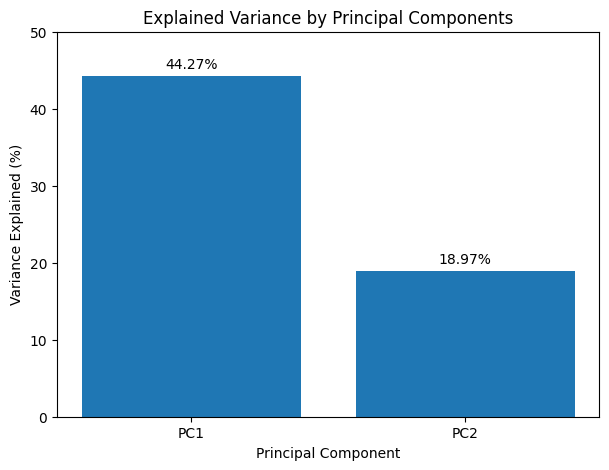

In [7]:
# Task 6: Analyze Explained Variance Ratio

print("========== EXPLAINED VARIANCE ANALYSIS ==========")

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Display individual variance
print("\nVariance Explained by PC1:")
print("{:.4f}".format(explained_variance[0]))

print("\nVariance Explained by PC2:")
print("{:.4f}".format(explained_variance[1]))

# Convert to percentage
print("\nPC1 Variance Explained: {:.2f}%".format(
    explained_variance[0] * 100
))

print("PC2 Variance Explained: {:.2f}%".format(
    explained_variance[1] * 100
))

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative Variance:")
for i, value in enumerate(cumulative_variance):
    print("PC{}: {:.2f}%".format(i + 1, value * 100))

# Total variance retained
total_variance = cumulative_variance[-1] * 100

print("\nTotal Variance Retained by PC1 + PC2: {:.2f}%".format(
    total_variance
))

# Plot explained variance ratio

components = ['PC1', 'PC2']
variance_percent = explained_variance * 100

plt.figure(figsize=(7, 5))

plt.bar(
    components,
    variance_percent
)

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")

plt.ylim(0, 50)

for i, value in enumerate(variance_percent):
    plt.text(
        i,
        value + 1,
        "{:.2f}%".format(value),
        ha='center'
    )

plt.show()

# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

========== PCA 2D VISUALIZATION ==========


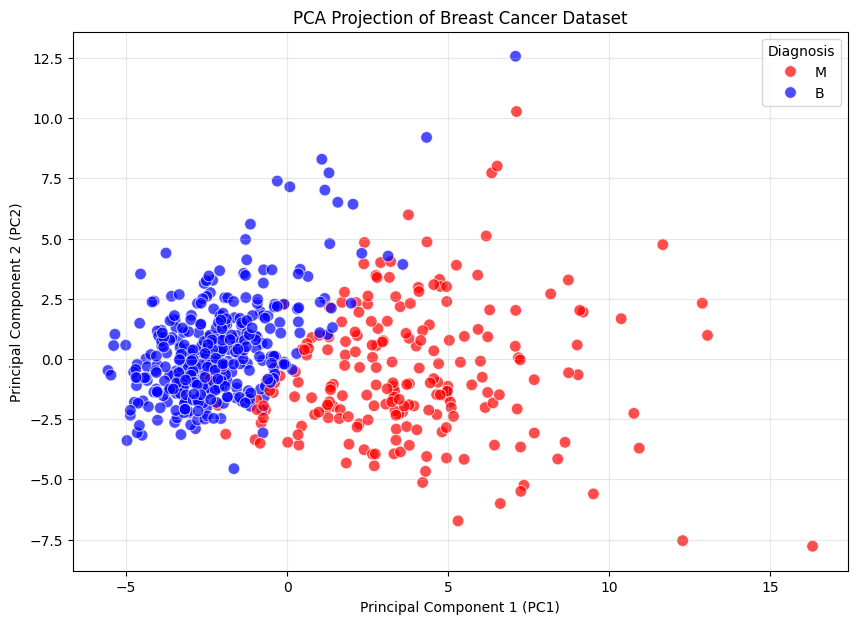

In [8]:
# Task 7: Visualize PCA Transformed Data

print("========== PCA 2D VISUALIZATION ==========")

# Create a DataFrame for PCA results
pca_plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Diagnosis': df['diagnosis']
})

# Create scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_plot_df,
    x='PC1',
    y='PC2',
    hue='Diagnosis',
    palette={'B': 'blue', 'M': 'red'},
    s=70,
    alpha=0.7
)

plt.title("PCA Projection of Breast Cancer Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Diagnosis")

plt.grid(alpha=0.3)
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [9]:
# Task 8: Train Classifier on Raw High-Dimensional Data

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("========== TASK 8: LOGISTIC REGRESSION ==========")

# Split the standardized 30-feature data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Create Logistic Regression model
model_raw = LogisticRegression(max_iter=10000)

# Train the model
model_raw.fit(X_train, y_train)

# Predict test data
y_pred_raw = model_raw.predict(X_test)

# Calculate accuracy
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("\nAccuracy:")
print("{:.2f}%".format(accuracy_raw * 100))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_raw = confusion_matrix(y_test, y_pred_raw)
print(cm_raw)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_raw))

========== TASK 8: LOGISTIC REGRESSION ==========
Training data shape: (455, 30)
Testing data shape: (114, 30)

Accuracy:
96.49%

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [10]:
# Task 9: Train Classifier on PCA Transformed Data

print("========== TASK 9: LOGISTIC REGRESSION WITH PCA ==========")

# Split the PCA-transformed data
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_pca_train.shape)
print("Testing data shape:", X_pca_test.shape)

# Create Logistic Regression model
model_pca = LogisticRegression(max_iter=10000)

# Train the model
model_pca.fit(X_pca_train, y_pca_train)

# Predict test data
y_pred_pca = model_pca.predict(X_pca_test)

# Calculate accuracy
accuracy_pca = accuracy_score(y_pca_test, y_pred_pca)

print("\nAccuracy:")
print("{:.2f}%".format(accuracy_pca * 100))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_pca = confusion_matrix(y_pca_test, y_pred_pca)
print(cm_pca)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_pca_test, y_pred_pca))

========== TASK 9: LOGISTIC REGRESSION WITH PCA ==========
Training data shape: (455, 2)
Testing data shape: (114, 2)

Accuracy:
93.86%

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [11]:
# Task 10: Compare Classifier Performance

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("=" * 60)
print("       TASK 10: MODEL PERFORMANCE COMPARISON")
print("=" * 60)

# =========================================================
# Model 1: Logistic Regression using 30 original features
# =========================================================

print("\n----- MODEL 1: ORIGINAL 30 FEATURES -----")

accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("Accuracy: {:.2f}%".format(accuracy_raw * 100))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_raw))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_raw))


# =========================================================
# Model 2: Logistic Regression using 2 PCA features
# =========================================================

print("\n----- MODEL 2: PCA 2 FEATURES -----")

accuracy_pca = accuracy_score(y_pca_test, y_pred_pca)

print("Accuracy: {:.2f}%".format(accuracy_pca * 100))

print("\nConfusion Matrix:")
print(confusion_matrix(y_pca_test, y_pred_pca))

print("\nClassification Report:")
print(classification_report(y_pca_test, y_pred_pca))


# =========================================================
# Comparison Table
# =========================================================

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (30 Features)',
        'Logistic Regression (2 PCA Features)'
    ],
    'Number of Features': [
        30,
        2
    ],
    'Accuracy (%)': [
        accuracy_raw * 100,
        accuracy_pca * 100
    ]
})

print("\n========== FINAL COMPARISON ==========")
display(comparison)

       TASK 10: MODEL PERFORMANCE COMPARISON

----- MODEL 1: ORIGINAL 30 FEATURES -----
Accuracy: 96.49%

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


----- MODEL 2: PCA 2 FEATURES -----
Accuracy: 93.86%

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114


========== FINAL COMPARISON ==========


,Model,Number of Features,Accuracy (%)
0,Logistic Regression (30 Features),30,96.491228
1,Logistic Regression (2 PCA Features),2,93.859649


# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.